# Chapter 7 | Ensemble Methods

## Table of Contents
1. [Introduction](#1.-introduction)
2. [Voting Classifier](#2.-voting-classifier)
3. [Bagging and Pasting](#3.-bagging-and-pasting)
   - [Out-of-Bag Evaluation](#out-of-bag-evaluation)
   - [Random Patches and Random Subspaces](#random-patches-and-random-subspaces-sampling-features-andor-instances)
   - [Random Forests](#random-forests)
4.

## 1. Introduction
An **Ensemble** is defined as a **group of predictors**. The idea is that aggregating the predictions of a group of predictors, we'll often get a better predictions that with the best individual predictor (similarly to asking to random people a question and then aggregating the answers will take to a better answer).

One of the most used Ensemble Algorithms is **Random Forest**, which is an ensemble of decision trees; despite the simplicity, it's one of the most powerful ML algorithms today.

## 2. Voting Classifier
It's an **Ensemble Method** for classification; we have 2 main type of **Voting Classifier**:
- **Hard Voting Classifier**: aggregate the predictions of different classifiers by assigning the class with most votes;
- **Soft Voting Classifier**: aggregate the predictions of different classifiers by assigning the highest average class probability (this requires all classifiers to be able to estimate class probabilities).

(Soft Voting usually takes to better results, but it is not always usable due to the need for class probabilities)

These 2 simple methods already take to improve the accuracy classifier by aggregating them, even if they are weak classifiers (provided there are sufficient number of classifiers and that they are sufficiently diverse each other); to better understand this, let's try with an analogy:

suppose to have a biased coin with 51% chance of heads and 49% of tails (this is our weak binary classifier with 51% accuracy); tossing it 1000 times (having 1000 different weak classifiers) takes to around 75% heads (accuracy around 75%); tossing it 10000 times takes to around 97% accuracy!

This is due to the **Law of Large Numbers**:

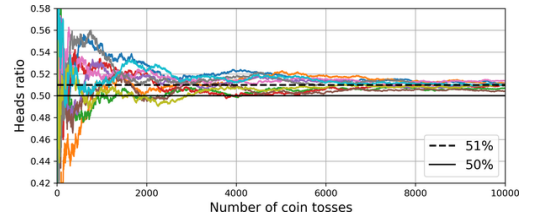

Of course, classifiers are not exactly like coin flips, because they are not perfectly independent each other (they are trained on the same data), but the more diverse they are, the more chance they will make different types of error there is, so the more the ensemble will be useful.

We can implement a voting classifier with the class `VotingClassifier` by Scikit-Learn (this will be an Hard Voting Classifier by default, but can become a Soft one if we set the hyperparameter `voting="soft"`, and if all classifiers can estimate class probabilities):

In [1]:
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('svc', SVC(random_state=42))
    ]
)
voting_clf.fit(X_train, y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


Let's first see the individual classifier's accuracy (on test set):

In [2]:
for name, clf in voting_clf.named_estimators_.items():
    print(name, '=', clf.score(X_test, y_test))

lr = 0.864
rf = 0.896
svc = 0.896


We can make predictions with the Hard Voting Classifier with the `predict()` method:

In [3]:
voting_clf.predict(X_test[:1])

array([1])

Let's now look at the Hard Voting Classifier performance:

In [4]:
voting_clf.score(X_test, y_test)

0.912

It outperforms the individual ones!

Let's now fit a Soft Voting Classifier (to do so, we need all our classifiers to estimate class probabilities, which doesn't happen to be the case for `SVC`; but as we know, in `SVC` we can put `probability=True` to allow SVC to use CV to estimate class probabilities):

In [5]:
voting_clf.voting = 'soft'
voting_clf.named_estimators['svc'].probability = True
voting_clf.fit(X_train, y_train)
voting_clf.score(X_test, y_test)

0.92

Even better!

## 3. Bagging and Pasting

While with Voting Classifier the idea was to use very different training algorithms, **Bagging** and **Boosting** are 2 approaches both involving using as predictors the same algorithm, but trained on different random subsets of the training set:
- **Bagging**: the random sampling is performed **with Replacement** (bagging is short for "bootstrap aggregating");
- **Pasting**: the random sampling is performed **without Replacement**.

Once all predictors are trained, the predictions are aggregated by an aggregating function: in classification soft voting is performed whenever is possible, otherwise hard voting; in regression average is typically performed.

In Scikit-Learn, we got the classes `BaggingClassifier` and `BaggingRegressor`; by default the hyperparameter `bootstrap` is set to `True`, so they perform Bagging (set it to `False` to perform Pasting); another useful parameter is `n_jobs`, which tells the number of CPU cores to use for training and predictions (if set to `-1` means to use all available cores).

In [6]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(), 
    n_estimators=500,
    max_samples=100,
    n_jobs=-1,
    random_state=42
)

bag_clf.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,500
,max_samples,100
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


Below a comparison of the Decision Boundaries of 1 decision tree (left) and the above Bagging Classifier:

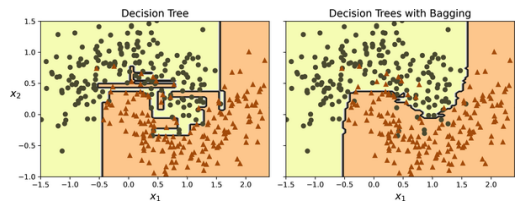

As we can see, ensemble's prediction will likely generalize better (similar bias, but smaller variance).

Talking about which is better between Bagging and Pasting, Bagging usually takes to higher bias (more diversity in the subsets on which each predictor is trained on), which takes to extra diversity and less correlation between predictors, which generally takes to lower variance (and better performance). Given that, Bagging is generally preferred to Pasting.

### Out-of-Bag Evaluation

When training a `BaggingClassifier` with replacement (Bagging), it can be shown matematically that only abouy 63% of training instances are sampled on average for each predictor; the remaining 37% training instances are called **Out-of-Bag (OOB)** instances (note how they are not the same 37% for all predictors).

One smart thing we can do is use these OOB instances to evaluate the bagging ensemble, without the need for a separate validation set. This can be done in Scikit-Learn by putting `oob_score=True` in `BaggingClassifier`:

In [7]:
bag_clf = BaggingClassifier(DecisionTreeClassifier(), n_estimators=500, oob_score=True, n_jobs=-1, random_state=42)
bag_clf.fit(X_train, y_train)
bag_clf.oob_score_


0.896

The OOB evaluation is estimating an ccuracy of 89.6% on the test set; let's check:

In [8]:
from sklearn.metrics import accuracy_score
y_pred = bag_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

The OOB evaluation was a bit pessimistic in this case, but it is quite accurate.

We can also access the OOB decision function for each training instances (given that the individual classifier can estimate class probabilities):

In [9]:
bag_clf.oob_decision_function_[:3].round(3)

array([[0.324, 0.676],
       [0.338, 0.662],
       [1.   , 0.   ]])

First observation has 32.4% of belonging to Negative Class, 67.6% of belonging to Positive Class, and so on.

### Random Patches and Random Subspaces (Sampling Features and/or Instances)
The `BaggingClassifier` supports **sampling features** aswell; this can be controlled by the 2 hyperparameters `max_features` and `bootstrap_features`, which work the same way as `max_samples` and `bootstrap`, but for features instead of instances. This is particularly useful with high-dimensional inputs (e.g., images) to speed up training.

We can distinguish between 2 methods:
- **Random Patches Method**: **sampling both training instances and features**;
- **Random Subspaces Method**: **keeping all instances** (`bootstrap=False` and `max_samples=1.0`) but **sampling features** (`bootstrap_features=True` and/or `max_features` smaller than 1.0)

Sampling features takes bit more bias for lower variance.

### Random Forests
A **Random Forest** is an enseble of decision trees, typically trained via bagging and with `max_samples` set to size of training set.

Instead of passing a `DecisionTreeClassifier` to a `BaggingClassifier`, we have the `RandomForestClassifier` class (and `RandomForestRegressor` for regression). This classes have very similar hypeparametersd

In [10]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=500, max_leaf_nodes=16, n_jobs=-1, random_state=42)
rnd_clf.fit(X_train, y_train)

y_pred = rnd_clf.predict(X_test)